In [1]:
import pennylane as qml
import csv, os, math
import pennylane as qml
import torch
import numpy as np
import copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta

print('torch', torch.__version__, '| pennylane', qml.version())

torch 2.8.0+cpu | pennylane 0.42.3


In [2]:
# 2) 설정값
# - 논문에서는 이미지 해상도, 필터 크기, 학습 데이터 수(2500), 채널(8), head(64/10)만 나와있음

TRAIN_COUNT = 4000      # 학습에 사용할 훈련 샘플 수, 정확도 낮으니 올려보기
VAL_RATIO   = 0.1       # 훈련셋에서 검증으로 떼어둘 비율
TEST_COUNT  = 1000      # 테스트 샘플 수 (최대 10000)

CHANNELS    = 23         # 학습형 양자 필터(채널) 수
DEPTH       = 2         # 회전 블록 깊이(1부터 시작, 2면 느려지지만 표현력↑)
HIDDEN_UNITS= 64        # 분류기 MLP 은닉층 너비 (논문 데모는 64)
EPOCHS      = 10        # 너무 크게 두면 느립니다. 먼저 20~40 사이로 탐색
LR          = 5e-4      # 1e-3일 때 90, 다음은 5e-4로
WEIGHT_DECAY= 1e-4

BATCH_TRAIN = 64        # 파라미터-시프트 비용 고려
BATCH_VAL   = 128
BATCH_TEST  = 256

# 랜덤 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
# 3) 백엔드 설정
def make_device(wires=4, shots=None):
    try:
        dev = qml.device('lightning.qubit', wires=wires, shots=shots)
        print('[Backend] lightning.qubit')
    except Exception as e:
        print(f'[Backend] lightning.qubit 사용 불가 → default.qubit ({e})')
        dev = qml.device('default.qubit', wires=wires, shots=shots)
        print('[Backend] default.qubit')
    return dev

DEV = make_device(4, shots=None)  # 4큐빗 회로, 샷 없음(analytic)


[Backend] lightning.qubit


In [4]:
# MNIST 10×10
def load_mnist_10x10(train_count=TRAIN_COUNT, test_count=TEST_COUNT):
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((10,10)),
    ])
    train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=tfm)
    test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=tfm)
    x_train = torch.stack([train_ds[i][0] for i in range(train_count)])  # (N,1,10,10)
    y_train = torch.tensor([train_ds[i][1] for i in range(train_count)])
    x_test  = torch.stack([test_ds[i][0]  for i in range(test_count)])
    y_test  = torch.tensor([test_ds[i][1] for i in range(test_count)])
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_mnist_10x10()
print('data:', x_train.shape, x_test.shape)

data: torch.Size([4000, 1, 10, 10]) torch.Size([1000, 1, 10, 10])


In [5]:
def plot_sample(idx: int, split: str = "train"):
    
    X, Y = (x_train, y_train) if split == "train" else (x_test, y_test)
    if not (0 <= idx < len(X)):
        raise ValueError(f"idx 범위 초과: 0 <= idx < {len(X)}")

    img   = X[idx].squeeze(0).cpu()  # (10,10)
    label = int(Y[idx])

    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(f"{split} idx={idx}, label={label}")
    plt.axis("off")
    plt.show()

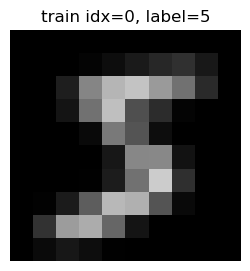

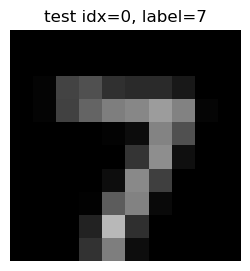

In [6]:
plot_sample(0, "train")
plot_sample(0, "test")

In [7]:
# 5) train/val split + DataLoader
def stratified_split(X, Y, val_ratio=0.1, seed=SEED):
    # 간단한 수동 층화 분할
    idx_by_cls = {c: (Y==c).nonzero(as_tuple=True)[0] for c in range(10)}
    tr_idx_list, va_idx_list = [], []
    g = torch.Generator().manual_seed(seed)
    for c, idxs in idx_by_cls.items():
        idxs = idxs[torch.randperm(len(idxs), generator=g)]
        n_val = max(1, int(len(idxs)*val_ratio))
        va_idx_list.append(idxs[:n_val])
        tr_idx_list.append(idxs[n_val:])
    tr_idx = torch.cat(tr_idx_list).tolist()
    va_idx = torch.cat(va_idx_list).tolist()
    return torch.tensor(tr_idx), torch.tensor(va_idx)

tr_idx, va_idx = stratified_split(x_train, y_train, VAL_RATIO, SEED)

train_loader = DataLoader(TensorDataset(x_train[tr_idx], y_train[tr_idx]),
                          batch_size=BATCH_TRAIN, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_train[va_idx], y_train[va_idx]),
                          batch_size=BATCH_VAL,   shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test, y_test),
                          batch_size=BATCH_TEST,  shuffle=False)

print(f"train/val/test sizes: {len(tr_idx)}/{len(va_idx)}/{len(x_test)}")


train/val/test sizes: 3604/396/1000


In [8]:
# 2×2 패치 → 4 큐빗 인코딩 + 얽힘 회로 + 랜덤 단일 큐빗 회전
def random_weights(seed=0):
    rng = np.random.default_rng(seed)
    return np.array(rng.uniform(0, 2*np.pi, size=(4,2)), dtype=np.float32)  # 각 큐빗 (RZ,RX)

@qml.qnode(DEV, interface='torch')
def patch_qnode(pix4, weights):
    # 데이터 인코딩: 입력 ∈ [0,1] → RX(pi*x)
    for w in range(4):
        qml.RX(np.pi * pix4[w], wires=w)
    # 얽힘 (CZ 체인)
    qml.CZ(wires=[0,1]); qml.CZ(wires=[2,3]); qml.CZ(wires=[0,2]); qml.CZ(wires=[1,3])
    # 랜덤 단일 큐빗 회전
    for w in range(4):
        qml.RZ(weights[w,0], wires=w)
        qml.RX(weights[w,1], wires=w)
    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
        qml.expval(qml.PauliZ(3)),
    )

WEIGHTS = [torch.tensor(random_weights(1000+c), dtype=torch.float32) for c in range(CHANNELS)]

In [9]:
# 6) 빠른 점검
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)  # (B,1,10,10), (B,)
print("min/max:", float(xb.min()), float(xb.max()))

batch shapes: torch.Size([64, 1, 10, 10]) torch.Size([64])
min/max: 0.0 0.99212247133255


In [10]:
# 7) 패치 추출: (N,1,10,10) -> (N,5,5,4)
def extract_patches_2x2_stride2_fast(x: torch.Tensor):
    uf = F.unfold(x, kernel_size=2, stride=2)            # (N, 4, 25)
    return uf.transpose(1, 2).contiguous().reshape(x.size(0), 5, 5, 4)


In [11]:
# 8) 학습형 양자 컨볼루션 레이어 (TorchLayer 활용, 배치는 수동 처리)

def make_qconv_torchlayer(depth: int):
    """2x2 패치(4값) -> 4큐빗 회로 -> ⟨Z⟩ 4개 반환. 파라미터 shape=(depth,4,3)."""
    @qml.qnode(DEV, interface='torch')
    def qconv_circuit(inputs, weights):  # ★ 첫 인자는 반드시 'inputs'
        # inputs: (4,) ∈ [0,1]  ->  RX(pi * x)
        for w in range(4):
            qml.RX(math.pi * inputs[w], wires=w)
        # 2x2 격자 얽힘
        qml.CZ(wires=[0,1]); qml.CZ(wires=[2,3])
        qml.CZ(wires=[0,2]); qml.CZ(wires=[1,3])
        # 학습 가능한 회전 블록
        for d in range(depth):
            for w in range(4):
                qml.Rot(weights[d, w, 0], weights[d, w, 1], weights[d, w, 2], wires=w)
        return [qml.expval(qml.PauliZ(i)) for i in range(4)]

    weight_shapes = {"weights": (depth, 4, 3)}
    # ★ n_batch_dims 사용 금지 (변환 데코레이터 경로 방지)
    return qml.qnn.TorchLayer(qconv_circuit, weight_shapes)

class QuantumConv2x2(nn.Module):
    """입력: (N,1,10,10) → 출력: (N,5,5, 4*C)  (C=채널 수)"""
    def __init__(self, channels: int = 8, depth: int = 1, micro_bs: int = 256):
        super().__init__()
        self.channels = channels
        self.filters = nn.ModuleList([make_qconv_torchlayer(depth) for _ in range(channels)])
        self.norm = nn.LayerNorm(channels*4)   # 마지막 차원 정규화
        self.micro_bs = micro_bs               # TorchLayer 단일 입력을 마이크로 배치로 처리

    def forward(self, x: torch.Tensor):
        N = x.size(0)
        patches = extract_patches_2x2_stride2_fast(x)     # (N,5,5,4)
        flat = patches.reshape(N * 25, 4)                 # (N*25, 4)

        outs = []
        for f in self.filters:
            # TorchLayer는 (4,) 단일만 안정 —> 마이크로 배치로 묶어서 반복
            ys = []
            for s in range(0, flat.size(0), self.micro_bs):
                chunk = flat[s:s+self.micro_bs]           # (m, 4)
                # chunk를 샘플 단위로 호출해서 stack
                chunk_out = torch.stack([f(v) for v in chunk], dim=0)  # (m, 4)
                ys.append(chunk_out)
            y = torch.cat(ys, dim=0)                      # (N*25, 4)
            outs.append(y)

        ycat = torch.cat(outs, dim=1)                     # (N*25, 4C)
        ycat = ycat.reshape(N, 5, 5, -1)                  # (N,5,5,4C)
        ycat = self.norm(ycat)
        return ycat


In [12]:
# 9) 전체 모델
class QCNNNet(nn.Module):
    def __init__(self, channels=CHANNELS, depth=DEPTH, hidden=HIDDEN_UNITS, p_drop=0.2):
        super().__init__()
        self.qconv = QuantumConv2x2(channels=channels, depth=depth)   # (N,5,5,4C)
        in_dim = 5*5*4*channels                                       # 25 * 4C = 100C
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 10)
        )
    def forward(self, x):
        feats = self.qconv(x)
        return self.head(feats)


In [13]:
# 10) 학습 유틸
def run_epoch(model, loader, loss_fn, opt=None):
    train_mode = opt is not None
    model.train() if train_mode else model.eval()
    tot_loss = 0.0; tot_corr = 0; tot_cnt = 0
    for xb, yb in loader:
        logits = model(xb)
        loss   = loss_fn(logits, yb)
        if train_mode:
            opt.zero_grad()
            loss.backward()  # <-- QConv까지 end-to-end로 역전파 (param-shift 내부 호출)
            opt.step()
        tot_loss += loss.item()*xb.size(0)
        tot_corr += (logits.argmax(1)==yb).sum().item()
        tot_cnt  += xb.size(0)
    return tot_loss/tot_cnt, tot_corr/tot_cnt


In [ ]:
# 11) 학습 루프 + CSV 로깅 + 테스트
# 학습 과정에서 dropout 사용, train data에 대한 별도의 테스트 필요

def eval_metrics(model, loader, loss_fn):
    """드롭아웃/정규화 차이를 없애기 위해 eval 모드에서 깔끔하게 재평가"""
    was_training = model.training
    model.eval()
    tot_loss=tot_corr=tot_cnt=0
    with torch.no_grad():
        for xb, yb in loader:
            lg = model(xb)
            ls = loss_fn(lg, yb)
            tot_loss += ls.item()*xb.size(0)
            tot_corr += (lg.argmax(1)==yb).sum().item()
            tot_cnt  += xb.size(0)
    if was_training:
        model.train()
    return tot_loss/tot_cnt, tot_corr/tot_cnt

def fit_and_eval(model, train_loader, val_loader, test_loader,
                 epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=10,
                 on_epoch_end=None):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)

    # 로그 파일 준비 (KST)
    os.makedirs("LearningLog", exist_ok=True)
    kst = timezone(timedelta(hours=9))
    ts  = datetime.now(kst).strftime("%Y%m%d%H%M")
    csv_path = os.path.join("LearningLog", f"LOG_{ts}.csv")

    # CSV 헤더 (train_eval_* 컬럼 추가)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow([
            "epoch",
            "train_loss","train_acc",
            "train_eval_loss","train_eval_acc",
            "val_loss","val_acc",
            "lr"
        ])

    # 히스토리
    hist = {
        "train_loss": [], "train_acc": [],
        "train_eval_loss": [], "train_eval_acc": [],
        "val_loss": [], "val_acc": [],
        "lr": []
    }

    best = float('inf'); best_state = None; wait = 0
    for ep in range(1, epochs+1):
        # -------- train (train 모드 지표) --------
        model.train()
        tr_loss=tr_corr=tr_cnt=0
        for xb, yb in train_loader:
            logits = model(xb)
            loss   = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item()*xb.size(0)
            tr_corr += (logits.argmax(1)==yb).sum().item()
            tr_cnt  += xb.size(0)
        tr_loss/=tr_cnt; tr_acc=tr_corr/tr_cnt

        # -------- val (eval 모드 지표) --------
        model.eval()
        va_loss=va_corr=va_cnt=0
        with torch.no_grad():
            for xb, yb in val_loader:
                lg = model(xb)
                ls = loss_fn(lg, yb)
                va_loss += ls.item()*xb.size(0)
                va_corr += (lg.argmax(1)==yb).sum().item()
                va_cnt  += xb.size(0)
        va_loss/=va_cnt; va_acc=va_corr/va_cnt

        # -------- train(eval) 재평가 (드롭아웃 OFF로 공정 비교) --------
        tr_eval_loss, tr_eval_acc = eval_metrics(model, train_loader, loss_fn)  # ★ 추가

        # 스케줄러/로그
        sched.step(va_loss)
        cur_lr = opt.param_groups[0]['lr']
        print(f"[{ep:02d}/{epochs}] train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f} | lr {cur_lr:.1e}")

        hist["train_loss"].append(tr_loss);        hist["train_acc"].append(tr_acc)
        hist["train_eval_loss"].append(tr_eval_loss); hist["train_eval_acc"].append(tr_eval_acc)   # ★ 추가
        hist["val_loss"].append(va_loss);          hist["val_acc"].append(va_acc)
        hist["lr"].append(cur_lr)

        with open(csv_path, "a", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow([
                ep,
                f"{tr_loss:.6f}", f"{tr_acc:.6f}",
                f"{tr_eval_loss:.6f}", f"{tr_eval_acc:.6f}",   # ★ 추가
                f"{va_loss:.6f}", f"{va_acc:.6f}",
                f"{cur_lr:.6e}"
            ])

        # 콜백(라이브 플롯 등)
        if on_epoch_end is not None:
            on_epoch_end(hist)

        # Early stopping
        if va_loss < best - 1e-4:
            best, best_state, wait = va_loss, {k:v.cpu() for k,v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep} (best val loss {best:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # -------- TEST --------
    test_loss=test_corr=test_cnt=0
    with torch.no_grad():
        for xb, yb in test_loader:
            lg = model(xb)
            ls = loss_fn(lg, yb)
            test_loss += ls.item()*xb.size(0)
            test_corr += (lg.argmax(1)==yb).sum().item()
            test_cnt  += xb.size(0)
    test_loss/=test_cnt; test_acc=test_corr/test_cnt
    print(f"[TEST] loss {test_loss:.4f} | acc {test_acc:.4f} | log: {csv_path}")

    return hist, csv_path, (test_loss, test_acc)


In [15]:
# 12) 학습/검증 곡선 - matplotlib 설정
import matplotlib
try:
    import matplotlib.pyplot as plt
except Exception:
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

from IPython.display import clear_output, display


def plot_learning_curves(hist):
    epochs = range(1, len(hist["val_loss"]) + 1)
    train_loss_key = "train_eval_loss" if "train_eval_loss" in hist else "train_loss"
    train_acc_key  = "train_eval_acc"  if "train_eval_acc"  in hist else "train_acc"
    train_label    = "train(eval)" if train_loss_key.startswith("train_eval") else "train"

    plt.figure(figsize=(6,4))
    plt.plot(epochs, hist[train_loss_key], label=train_label)
    plt.plot(epochs, hist["val_loss"],     label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, hist[train_acc_key], label=train_label)
    plt.plot(epochs, hist["val_acc"],     label="val")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy"); plt.legend()
    plt.show()

In [ ]:
# 13) 학습 실행

model = QCNNNet(channels=CHANNELS, depth=DEPTH, hidden=HIDDEN_UNITS, p_drop=0.2)
hist, csv_path, test_metrics = fit_and_eval(
    model, train_loader, val_loader, test_loader,
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=10
)
print("CSV saved to:", csv_path)
plot_learning_curves(hist)

[01/10] train 1.4654/0.545 | val 0.8334/0.816 | lr 5.0e-04
